In [ ]:
'''
This file is a first attempt to create some custom BMs 
based on the D-Wave Zephyr Graph architecture. 

As of 08/12/2025: 
What has been done: 
Mainly: 
- Generate Zephyr graph
- Assign visible & hidden nodes in the graph 
- Train the resulting BM

Also: 
- Removal of some poorly connected nodes in the graph
- Visualizations: Visible vs Hidden in Zephyr graph 

All this is using the previous functionalities from 
custom_bm.py, which implements the custom architecture 
BMs and handles the PCD, sampling, etc 
--> Improvements there make improvements here! 


To do: 
- Need a meaningful assignment of visible nodes to 
pixels in the image. Right now, it's just the order of labels in 
the graph nodes with order of pixel labels. 
    Probably: Group closeby pixels together somehow
- Speed things up (in custom_BMs, probably)
    --> GPU? 
    --> Faster Gibbs sampling (e.g. with Julia?)
    --> Partition the graph for block Gibbs sampling? 
        - Maybe just need to partition Zephyr graph once...
- Hyperparameter tuning (issue: it's slow to run)
    - Right now no images are looking good at all! 
    - Tune things to get good values. 


'''

'''
8/17/25

Tried assigning pixels to nodes in a way that preserves locality.
Instead of first 144 visible, I tried to group nearby pixels together using degrees of each node.

Also, trained using more gibbs step in training (5 -> 10), more epochs (20 -> 50 -> 100), 
'''

'''
8/24/25

Experimented with different assignments for visible. Specifically:
-> assigning second half as visible, and then using the 12x12 grid 
->  removing node relabling after node removal resulted
-> (*the first time I removed node relabling, and assigned second half as visible (no other changes), there was
        weirdly massive improvement in training (PCD ~0), and the samples looked better as well.
         Have been trying to figure out why it happened for just that run, and replicate it for now but no luck :(

8/30/25

Pre-emptive tuning (esp. lower learning rate) to get a decreasing avg PCD loss, which was a success but the quality of samples degraded.
I believe it was an overfitting issue then. 
'''

import dwave_networkx as dnx
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.transform import resize
import pandas as pd
import os
from torchvision import datasets, transforms


# Set default device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
np.random.seed(42)
random.seed(42)

# --- Config ---
GRID_SHAPE = (12,12)   # <-- change this to (12,12), (13,13), (14,14), etc.
num_visible = GRID_SHAPE[0] * GRID_SHAPE[1]
NUM_VISIBLE = num_visible  # for consistency with other files
grid_shape = GRID_SHAPE  # to be used in other files

#this is a class to use for the networkx graph to boltzmann machine conversion.
class BoltzmannMachineGraph:
    """
    Defines the Boltzmann Machine architecture based on a NetworkX graph
    and a mapping of nodes to visible/hidden units. Generates masks for weight matrices.
    """
    def __init__(self, graph: nx.Graph, node_labels):
        """
        Args:
            graph (nx.Graph): The undirected graph defining connections.
            node_labels (dict or list): A dictionary mapping node IDs to 'visible' or 'hidden'.
        """
        if not (isinstance(node_labels, dict) or isinstance(node_labels, np.ndarray)):
            raise TypeError("node_labels must be either a dict or a numpy array.")
        if isinstance(node_labels, np.ndarray):
            # Convert numpy array to dict: assume 0=visible, 1=hidden or vice versa
            node_labels = {i: 'visible' if label == 1 else 'hidden' for i, label in enumerate(node_labels)}
        self.graph = graph
        self.node_labels = node_labels

        if not all(label in ['visible', 'hidden'] for label in node_labels.values()):
            raise ValueError("Node labels must be 'visible' or 'hidden'.")
        if set(graph.nodes()) != set(node_labels.keys()):
            raise ValueError("All graph nodes must have a label in node_labels.")

        self.visible_nodes = sorted([node for node, label in node_labels.items() if label == 'visible'])
        self.hidden_nodes = sorted([node for node, label in node_labels.items() if label == 'hidden'])

        self.num_visible = len(self.visible_nodes)
        self.num_hidden = len(self.hidden_nodes)

        self.v_node_to_idx = {node: i for i, node in enumerate(self.visible_nodes)}
        self.h_node_to_idx = {node: i for i, node in enumerate(self.hidden_nodes)}

        self.mask_vv, self.mask_hh, self.mask_vh = self._generate_adjacency_masks()

    def _generate_adjacency_masks(self) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Generates boolean masks for W_vv, W_hh, and W_vh based on the graph."""
        mask_vv = torch.zeros(self.num_visible, self.num_visible, dtype=torch.bool, device=device)
        mask_hh = torch.zeros(self.num_hidden, self.num_hidden, dtype=torch.bool, device=device)
        mask_vh = torch.zeros(self.num_visible, self.num_hidden, dtype=torch.bool, device=device)

        for u, v in self.graph.edges():
            u_label, v_label = self.node_labels[u], self.node_labels[v]

            if u_label == 'visible' and v_label == 'visible':
                u_idx, v_idx = self.v_node_to_idx[u], self.v_node_to_idx[v]
                mask_vv[u_idx, v_idx] = True
                mask_vv[v_idx, u_idx] = True # Ensure symmetry for undirected graph

            elif u_label == 'hidden' and v_label == 'hidden':
                u_idx, v_idx = self.h_node_to_idx[u], self.h_node_to_idx[v]
                mask_hh[u_idx, v_idx] = True
                mask_hh[v_idx, u_idx] = True # Ensure symmetry for undirected graph

            else: # visible-hidden connection
                if u_label == 'visible':
                    u_idx, v_idx = self.v_node_to_idx[u], self.h_node_to_idx[v]
                else: # u_label is 'hidden'
                    u_idx, v_idx = self.v_node_to_idx[v], self.h_node_to_idx[u]
                mask_vh[u_idx, v_idx] = True

        mask_vv.fill_diagonal_(False)
        mask_hh.fill_diagonal_(False)

        return mask_vv, mask_hh, mask_vh


#this is a custom BM model through PyTorch, which defines 
# a lot of the relevant functions as methods in this class. 
# (e.g. energy, sampling, etc.)
class CustomBoltzmannMachine(nn.Module):
    """
    A PyTorch Boltzmann Machine with a custom architecture defined by masks.
    Supports binary units {0, 1}.
    """
    def __init__(self, bm_graph: BoltzmannMachineGraph, k_gibbs_positive: int = 3):
        super().__init__()
        self.bm_graph = bm_graph
        self.num_visible = bm_graph.num_visible
        self.num_hidden = bm_graph.num_hidden
        self.k_gibbs_positive = k_gibbs_positive

        self.register_buffer('mask_vv', bm_graph.mask_vv)
        self.register_buffer('mask_hh', bm_graph.mask_hh)
        self.register_buffer('mask_vh', bm_graph.mask_vh)

        self.W_vv_raw = nn.Parameter(torch.randn(self.num_visible, self.num_visible, device=device) * 0.01)
        self.W_hh_raw = nn.Parameter(torch.randn(self.num_hidden, self.num_hidden, device=device) * 0.01)
        self.W_vh_raw = nn.Parameter(torch.randn(self.num_visible, self.num_hidden, device=device) * 0.01)

        self.b_v = nn.Parameter(torch.zeros(self.num_visible, device=device))
        self.b_h = nn.Parameter(torch.zeros(self.num_hidden, device=device))

    def _get_masked_weights(self) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Applies masks and enforces symmetry for intra-layer weights."""
        W_vv = (self.W_vv_raw + self.W_vv_raw.T) / 2 * self.mask_vv
        W_hh = (self.W_hh_raw + self.W_hh_raw.T) / 2 * self.mask_hh
        W_vh = self.W_vh_raw * self.mask_vh
        return W_vv, W_hh, W_vh

    def energy(self, v: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        """
        Computes the energy of a given state (v, h).
        E(v,h) = -0.5*v'W_vv*v - 0.5*h'W_hh*h - v'W_vh*h - b_v'*v - b_h'*h
        """
        W_vv, W_hh, W_vh = self._get_masked_weights()
        if v.dim() == 1: v = v.unsqueeze(0)
        if h.dim() == 1: h = h.unsqueeze(0)

        term_vv = -0.5 * torch.sum(v @ W_vv * v, dim=1)
        term_hh = -0.5 * torch.sum(h @ W_hh * h, dim=1)
        term_vh = -torch.sum((v @ W_vh) * h, dim=1)
        term_bv = -v @ self.b_v
        term_bh = -h @ self.b_h

        return term_vv + term_hh + term_vh + term_bv + term_bh

    def _compute_local_field_v(self, v_current: torch.Tensor, h_current: torch.Tensor, unit_idx: int, W_vv: torch.Tensor, W_vh: torch.Tensor) -> torch.Tensor:
        """Computes the local field for a single visible unit v_i."""
        # Exclude self-connection by masking out the diagonal
        v_masked = v_current.clone()
        v_masked[:, unit_idx] = 0  # Zero out the unit being updated
        
        field_vv = v_masked @ W_vv[:, unit_idx]
        field_vh = h_current @ W_vh[unit_idx, :].T
        return field_vv + field_vh + self.b_v[unit_idx]

    def _compute_local_field_h(self, v_current: torch.Tensor, h_current: torch.Tensor, unit_idx: int, W_hh: torch.Tensor, W_vh: torch.Tensor) -> torch.Tensor:
        """Computes the local field for a single hidden unit h_j."""
        # Exclude self-connection by masking out the diagonal
        h_masked = h_current.clone()
        h_masked[:, unit_idx] = 0  # Zero out the unit being updated
        
        field_hh = h_masked @ W_hh[:, unit_idx]
        field_hv = v_current @ W_vh[:, unit_idx]
        return field_hh + field_hv + self.b_h[unit_idx]

    @staticmethod
    def _sample_unit_given_field(field: torch.Tensor) -> torch.Tensor:
        """Helper to sample a binary unit given its local field."""
        prob = torch.sigmoid(field)
        return torch.bernoulli(prob)

    def gibbs_sample_step_no_grad(self, v_current: torch.Tensor, h_current: torch.Tensor, 
                                  update_v: bool = True, update_h: bool = True) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Performs one full single-site Gibbs sampling step WITHOUT gradient tracking.
        This version is used for sampling during training to avoid in-place operation errors.
        """
        # Detach inputs to prevent gradient tracking
        v_next = v_current.detach().clone()
        h_next = h_current.detach().clone()
        
        # Get weights without gradients for sampling
        with torch.no_grad():
            W_vv, W_hh, W_vh = self._get_masked_weights()
            W_vv = W_vv.detach()
            W_hh = W_hh.detach()
            W_vh = W_vh.detach()

            #OLD method, not vectorized!
            if update_v:
                    # Sequentially update each visible unit
                    for i in torch.randperm(self.num_visible):
                        field_v_i = self._compute_local_field_v(v_next, h_next, i, W_vv, W_vh)
                        v_next[:, i] = self._sample_unit_given_field(field_v_i)

            if update_h:
                # Sequentially update each hidden unit
                for j in torch.randperm(self.num_hidden):
                    field_h_j = self._compute_local_field_h(v_next, h_next, j, W_hh, W_vh)
                    h_next[:, j] = self._sample_unit_given_field(field_h_j)

        return v_next, h_next

    def gibbs_sample_step(self, v_current: torch.Tensor, h_current: torch.Tensor, 
                          update_v: bool = True, update_h: bool = True) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Performs one full single-site Gibbs sampling step WITH gradient tracking.
        This version is used for inference/generation after training.
        """
        v_next = v_current.clone()
        h_next = h_current.clone()
        
        W_vv, W_hh, W_vh = self._get_masked_weights()

        if update_v:
            # Sequentially update each visible unit
            for i in torch.randperm(self.num_visible):
                field_v_i = self._compute_local_field_v(v_next, h_next, i, W_vv, W_vh)
                v_next[:, i] = self._sample_unit_given_field(field_v_i)

        if update_h:
            # Sequentially update each hidden unit
            for j in torch.randperm(self.num_hidden):
                field_h_j = self._compute_local_field_h(v_next, h_next, j, W_hh, W_vh)
                h_next[:, j] = self._sample_unit_given_field(field_h_j)

        return v_next, h_next

    def mean_field_update(self, v: torch.Tensor, h: torch.Tensor, 
                         update_v: bool = True, update_h: bool = True) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Performs a mean-field update (deterministic) instead of sampling.
        This can be used for the positive phase to avoid sampling issues.
        """
        W_vv, W_hh, W_vh = self._get_masked_weights()
        v_next = v.clone()
        h_next = h.clone()

        # # old, not vectorized! 
        if update_v:
            for i in range(self.num_visible):
                field_v_i = self._compute_local_field_v(v_next, h_next, i, W_vv, W_vh)
                v_next[:, i] = torch.sigmoid(field_v_i)
        
        if update_h:
            for j in range(self.num_hidden):
                field_h_j = self._compute_local_field_h(v_next, h_next, j, W_hh, W_vh)
                h_next[:, j] = torch.sigmoid(field_h_j)
                
        return v_next, h_next

    def forward(self, v_data: torch.Tensor, k_steps: int = 1) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Performs the Contrastive Divergence (CD-k) update.
        Uses mean-field for positive phase and sampling for negative phase.
        """
        batch_size = v_data.shape[0]
        v_pos = v_data.to(device)

        # --- Positive Phase: Use mean-field approximation ---
        # Initialize hidden units
        h_pos = torch.full((batch_size, self.num_hidden), 0.5, device=device)
        
        # Run mean-field updates to get approximate posterior
        for _ in range(self.k_gibbs_positive):
            v_pos, h_pos = self.mean_field_update(v_pos, h_pos, update_v=False, update_h=True)

        # --- Negative Phase: Use sampling ---
        # Start from positive phase but detached
        v_neg = v_pos.detach().clone()
        h_neg = h_pos.detach().clone()
        
        # Sample from the model
        for _ in range(k_steps):
            v_neg, h_neg = self.gibbs_sample_step_no_grad(v_neg, h_neg, update_v=True, update_h=True)

        # --- Loss Calculation ---
        pos_energy = self.energy(v_pos, h_pos).mean()
        neg_energy = self.energy(v_neg, h_neg).mean()
        cd_loss = pos_energy - neg_energy

        return cd_loss, v_neg

# --------------------------------------------------------------------------



#function to take a graph as input and turn it into a BM with 
# corresponding architecture. 
def graph_to_bm(G, node_labels) -> CustomBoltzmannMachine:
    """
    Factory function that takes a graph and node labels and returns a PyTorch
    Boltzmann Machine model.

    Returns:
        CustomBoltzmannMachine: The initialized PyTorch model.
    """
    print("Building Boltzmann Machine from graph... 🏗️")
    bm_architecture = BoltzmannMachineGraph(G, node_labels)
    model = CustomBoltzmannMachine(bm_architecture).to(device)
    return model

# Coverts the graph to a Boltzmann Machine and visualizes it.
def visualize_bm_bipartite_layout(G, node_labels, figsize=(10, 6), title="BM Graph - Bipartite Style"):
    import matplotlib.pyplot as plt
    import networkx as nx

    # Split nodes
    visible_nodes = [n for n, t in node_labels.items() if t == 'visible']
    hidden_nodes = [n for n, t in node_labels.items() if t == 'hidden']

    # Manually define bipartite-style positions
    pos = {}

    # Stack visible nodes vertically on the left
    for i, node in enumerate(sorted(visible_nodes)):
        pos[node] = (0, i)

    # Stack hidden nodes vertically on the right
    for i, node in enumerate(sorted(hidden_nodes)):
        pos[node] = (1, i)

    plt.figure(figsize=figsize)

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=visible_nodes, node_color='skyblue', label='Visible', node_size=100)
    nx.draw_networkx_nodes(G, pos, nodelist=hidden_nodes, node_color='salmon', label='Hidden', node_size=100)

    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.5)

    # Optionally add labels (can comment out if cluttered)
    # nx.draw_networkx_labels(G, pos, font_size=6)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.legend()
    plt.show()

# --------------------------------------------------------------------------
# Training: using CD here, though this is relatively flexibly written. 
def train_boltzmann_machine_cd(model: CustomBoltzmannMachine, data_loader: torch.utils.data.DataLoader,
                            optimizer: torch.optim.Optimizer, num_epochs: int, k_steps: int,
                            batch_size: int = 64, step_size: float = 0.001):
    """
    Trains the Boltzmann Machine using Contrastive Divergence.
    batch_size: Number of samples per batch.
    step_size: Learning rate for optimizer.
    """
    loss_history = []
    model.train()
    print(f"Starting training on {device} for {num_epochs} epochs... 🏋️")
    # Update optimizer learning rate if step_size is provided
    for param_group in optimizer.param_groups:
        param_group['lr'] = step_size

    # Re-create data_loader with new batch_size if needed
    if hasattr(data_loader, 'batch_size') and data_loader.batch_size != batch_size:
        dataset = data_loader.dataset
        data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_data in data_loader:
            batch = batch_data[0].to(device)
            optimizer.zero_grad()
            loss, _ = model(batch, k_steps=k_steps)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(data_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Avg CD Loss: {avg_loss:.4f}")
    print("Training complete! ✅")
    return loss_history

# Training with Persistent Contrastive Divergence (PCD)
def train_boltzmann_machine_pcd(model: CustomBoltzmannMachine, data_loader: torch.utils.data.DataLoader,
                                optimizer: torch.optim.Optimizer, num_epochs: int, k_steps: int = 1,
                                batch_size: int = 64, step_size: float = 0.001):
    """
    Trains the Boltzmann Machine using Persistent Contrastive Divergence (PCD).
    Maintains persistent chains across batches and epochs.
    """
    loss_history = []
    model.train()
    print(f"Starting PCD training on {device} for {num_epochs} epochs... 🏋️")

    for param_group in optimizer.param_groups:
        param_group['lr'] = step_size

    if hasattr(data_loader, 'batch_size') and data_loader.batch_size != batch_size:
        dataset = data_loader.dataset
        data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Persistent chains (initialized during first batch)
    persistent_v = None
    persistent_h = None

    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_data in data_loader:
            batch = batch_data[0].to(device)
            current_batch_size = batch.shape[0]

            # Initialize or resize persistent chains
            if (persistent_v is None) or (persistent_v.shape[0] != current_batch_size):
                persistent_v = torch.bernoulli(torch.full((current_batch_size, model.num_visible), 0.5, device=device))
                persistent_h = torch.bernoulli(torch.full((current_batch_size, model.num_hidden), 0.5, device=device))

            optimizer.zero_grad()

            # --- Positive Phase (mean-field approx) ---
            v_pos = batch
            h_pos = torch.full((current_batch_size, model.num_hidden), 0.5, device=device)
            for _ in range(model.k_gibbs_positive):
                v_pos, h_pos = model.mean_field_update(v_pos, h_pos, update_v=False, update_h=True)

            # --- Negative Phase (persistent chain) ---
            v_neg = persistent_v.clone()
            h_neg = persistent_h.clone()
            for _ in range(k_steps):
                v_neg, h_neg = model.gibbs_sample_step_no_grad(v_neg, h_neg, update_v=True, update_h=True)

            # Update persistent chain
            persistent_v = v_neg.detach()
            persistent_h = h_neg.detach()

            # --- Loss ---
            pos_energy = model.energy(v_pos, h_pos).mean()
            neg_energy = model.energy(v_neg, h_neg).mean()
            pcd_loss = pos_energy - neg_energy

            pcd_loss.backward()
            optimizer.step()
            total_loss += pcd_loss.item()

        avg_loss = total_loss / len(data_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Avg PCD Loss: {avg_loss:.4f}")
    print("PCD training complete! ✅")
    return loss_history



#SAMPLING -- this can maybe be improved? ned to test the vectorized version more and think. 
def sample_from_bm(model: CustomBoltzmannMachine, num_samples: int, burn_in_steps: int,
                   method: str = 'gibbs', annealing_schedule: list[float] | None = None) -> torch.Tensor:
    """
    Samples visible unit configurations from the trained Boltzmann Machine.
    """
    model.eval()
    
    samples = []
    if method == 'gibbs':
        print(f"Running Gibbs sampler for {num_samples} samples, {burn_in_steps} burn-in steps each... 🔥")
        with torch.no_grad():
            for n in range(num_samples):
                v = torch.bernoulli(torch.full((1, model.num_visible), 0.5, device=device))
                h = torch.bernoulli(torch.full((1, model.num_hidden), 0.5, device=device))
                for step in range(burn_in_steps):
                    v, h = model.gibbs_sample_step(v, h)
                samples.append(v.squeeze(0).clone())
                if (n + 1) % (max(1, num_samples // 10)) == 0:
                    print(f"  Gibbs sample {n+1}/{num_samples}")
        print("Gibbs sampling complete.")
        return torch.stack(samples, dim=0)

    elif method == 'simulated_annealing':
        print(f"Running Simulated Annealing for {num_samples} samples, {burn_in_steps} steps each... ❄️")
        if annealing_schedule is None:
            annealing_schedule = np.logspace(np.log10(10.0), np.log10(1), burn_in_steps)

        if len(annealing_schedule) != burn_in_steps:
            raise ValueError("Length of annealing_schedule must match burn_in_steps.")

        W_vv, W_hh, W_vh = model._get_masked_weights()
        W_vv = W_vv.detach()
        W_hh = W_hh.detach()
        W_vh = W_vh.detach()

        with torch.no_grad():
            for n in range(num_samples):
                v = torch.bernoulli(torch.full((1, model.num_visible), 0.5, device=device))
                h = torch.bernoulli(torch.full((1, model.num_hidden), 0.5, device=device))
                for step, temp in enumerate(annealing_schedule):
                    # Visible units
                    for i in torch.randperm(model.num_visible):
                        field_v = model._compute_local_field_v(v, h, i, W_vv, W_vh)
                        delta_E = field_v * (1.0 - 2.0 * v[:, i])
                        accept_prob = torch.exp(-delta_E / temp).clamp(0, 1)
                        flip_mask = torch.bernoulli(accept_prob).bool()
                        v[flip_mask, i] = 1.0 - v[flip_mask, i]

                    # Hidden units
                    for j in torch.randperm(model.num_hidden):
                        field_h = model._compute_local_field_h(v, h, j, W_hh, W_vh)
                        delta_E = field_h * (1.0 - 2.0 * h[:, j])
                        accept_prob = torch.exp(-delta_E / temp).clamp(0, 1)
                        flip_mask = torch.bernoulli(accept_prob).bool()
                        h[flip_mask, j] = 1.0 - h[flip_mask, j]
                samples.append(v.squeeze(0).clone())
                if (n + 1) % (max(1, num_samples // 10)) == 0:
                    print(f"  SA sample {n+1}/{num_samples}")
        print("Simulated Annealing complete.")
        return torch.stack(samples, dim=0)
    else:
        raise ValueError("Method must be 'gibbs' or 'simulated_annealing'.")


# --- Tabu Search to Improve Sample Likelihood ---
def tabu_search_bm(model, v_init, h_init=None, steps=5, tabu_size=10):
    """
    Performs Tabu Search to locally improve the likelihood of a visible sample under the BM.
    Only flips one bit at a time, keeps a tabu list of recent states.
    This is to make the produced samples post-training nicer. 
    """
    v = v_init.clone().detach()
    if h_init is None:
        # Use mean-field to initialize hidden units
        h = torch.full((1, model.num_hidden), 0.5, device=device)
        for _ in range(model.k_gibbs_positive):
            _, h = model.mean_field_update(v, h, update_v=False, update_h=True)
    else:
        h = h_init.clone().detach()

    tabu_list = []
    best_v = v.clone()
    best_h = h.clone()
    best_energy = model.energy(v, h).item()

    for step in range(steps):
        candidates = []
        energies = []
        for i in range(model.num_visible):
            v_candidate = v.clone()
            v_candidate[0, i] = 1.0 - v_candidate[0, i]  # Flip bit
            # Check if candidate is in tabu list
            if any(torch.equal(v_candidate, t) for t in tabu_list):
                continue
            # Update hidden units using mean-field
            h_candidate = h.clone()
            _, h_candidate = model.mean_field_update(v_candidate, h_candidate, update_v=False, update_h=True)
            energy = model.energy(v_candidate, h_candidate).item()
            candidates.append((v_candidate, h_candidate))
            energies.append(energy)
        if not candidates:
            break
        min_idx = int(np.argmin(energies))
        v, h = candidates[min_idx]
        tabu_list.append(v.clone())
        if len(tabu_list) > tabu_size:
            tabu_list.pop(0)
        if energies[min_idx] < best_energy:
            best_v = v.clone()
            best_h = h.clone()
            best_energy = energies[min_idx]
    return best_v.squeeze(0)



Loading dataset...
Found existing .\mnist12x12_trainfeats.npy and .\mnist12x12_trainlabels.npy.
Found existing .\mnist12x12_testfeats.npy and .\mnist12x12_testlabels.npy.
After flattening, X_data shape: torch.Size([200, 144])


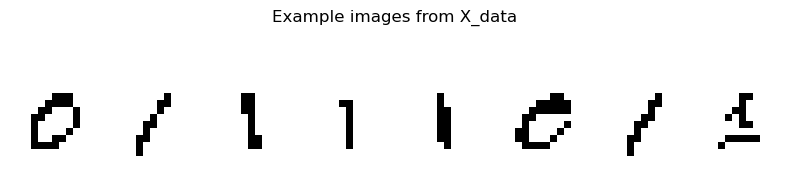

In [26]:

# --- Dataset Loading ---
# Using torchvision to download MNIST and then resize
def generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE, cutoff=0.5):
    """
    Generates downsized MNIST .npy files (from torchvision MNIST, not CSV).
    Resizes 28x28 MNIST images to `grid_shape` (e.g., 12x12, 13x13).
    Saves features and labels as .npy for reuse.
    """
    os.makedirs(output_dir, exist_ok=True)

    def process_dataset(dataset, cutoff):
        downsized, labels = [], []
        for img, label in dataset:
            # torchvision MNIST returns a PIL image unless transform is ToTensor
            img_np = np.array(img, dtype=np.float32)

            # If shape is (28,28,1), squeeze it
            if img_np.ndim == 3:
                img_np = img_np.squeeze(-1)

            img_np = img_np / 255.0  # scale to [0,1]
            img_small = resize(img_np, grid_shape, order=1, anti_aliasing=True, preserve_range=True)

            img_bin = (img_small >= cutoff).astype(np.uint8)
            downsized.append(img_bin.flatten())
            labels.append(label)
        return np.array(downsized), np.array(labels)

    # Load MNIST from torchvision (downloads automatically if not present)
    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=None)
    test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=None)

    for split, dataset in [("train", train_data), ("test", test_data)]:
        out_feats = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}feats.npy")
        out_labels = os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_{split}labels.npy")
        if not (os.path.exists(out_feats) and os.path.exists(out_labels)):
            print(f"Generating {out_feats} and {out_labels}...")
            feats, labels = process_dataset(dataset, cutoff)
            print("Processed feats shape:", feats.shape) # Debug print
            np.save(out_feats, feats)
            np.save(out_labels, labels)
        else:
            print(f"Found existing {out_feats} and {out_labels}.")

    return (
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainfeats.npy")),
        np.load(os.path.join(output_dir, f"mnist{grid_shape[0]}x{grid_shape[1]}_trainlabels.npy"))
    )



# --- Dataset Loading ---
print("Loading dataset...")
try:
    mnist_feats, mnist_labels = generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE)
except FileNotFoundError as e:
    print("Error: Could not find MNIST CSVs. Falling back to synthetic data...")
    mnist_feats = np.random.rand(1000, NUM_VISIBLE) > 0.3
    mnist_feats = mnist_feats.astype(np.float32)
    mnist_labels = np.zeros(len(mnist_feats), dtype=np.float32)


# Only keep images with label 0 or 1
mnist_feats = mnist_feats[(mnist_labels == 0) | (mnist_labels == 1)]
mnist_labels = mnist_labels[(mnist_labels == 0) | (mnist_labels == 1)]


#cut size of dataset massively for faster training
num_images_to_use = 200
mnist_feats = mnist_feats[:num_images_to_use]  # Use only the first few images for quick testing
mnist_feats = (mnist_feats - mnist_feats.min()) / (mnist_feats.max() - mnist_feats.min())
# Binarize and create DataLoader
roundup_boost = 0
X_data = (torch.from_numpy(mnist_feats).float() < 0.5 + roundup_boost).float()
# Flatten from (N, 13, 13) → (N, 169)
if X_data.ndim == 3:
    X_data = X_data.view(X_data.shape[0], -1)

# Make sure shape is (num_samples, 169)
print("After flattening, X_data shape:", X_data.shape)

# Add labels explicitly, even if dummy, to avoid 1-tuple nesting
dummy_labels = torch.zeros(len(X_data))  
dataset = torch.utils.data.TensorDataset(X_data, dummy_labels)

# --- Visualize a few images from X_data ---
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_data[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle("Example images from X_data")
plt.tight_layout()
plt.show()

K = 5 n = 880 n/K = 176.0 n/(32*K^2) = 1.0
880


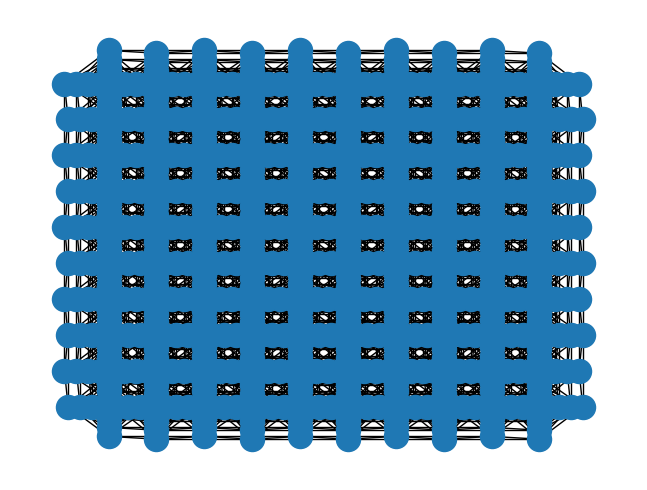

In [27]:
# Heler functions
# Get 2D positions for Zephyr nodes (Zephyr layout)
def get_zephyr_positions(G):
    try:
        # If available, this reflects physical qubit layout
        pos = dnx.zephyr_layout(G)  # dict: node -> (x, y)
    except Exception:
        # fallback: deterministic spring layout
        pos = nx.spring_layout(G, seed=42, dim=2)
    return pos

#  Assigning 144 visibles by laying a 12x12 grid over the layout and
#  greedily taking the nearest unique node to each grid cell center.
def assign_visibles_by_grid(G, grid_shape=GRID_SHAPE, min_degree=3):
    pos = get_zephyr_positions(G)
    nodes = np.array(sorted(G.nodes()))
    coords = np.array([pos[n] for n in nodes])  # shape (N, 2)
    if coords.size == 0:
        print("Warning: No eligible nodes found, relaxing min_degree constraint.")
        nodes = list(G.nodes())  # fallback: use all nodes
        coords = np.array([pos[n] for n in nodes])

    # grid centers across the layout bounding box
    xs, ys = coords[:, 0], coords[:, 1]
    xmin, xmax = xs.min(), xs.max()
    ymin, ymax = ys.min(), ys.max()

    nrows, ncols = grid_shape
    grid_x = np.linspace(xmin, xmax, ncols)
    # flip y so row 0 is top
    grid_y = np.linspace(ymax, ymin, nrows)

    selected = []
    used = set()

    # function to pick nearest unused node to target (x,y), optionally with min degree
    def pick_nearest(target_xy):
        # candidates not used yet
        mask = [n for n in nodes if n not in used]
        if not mask:
            raise RuntimeError("Ran out of nodes to assign as visibles")
        pts = np.array([pos[n] for n in mask])
        d2 = np.sum((pts - target_xy) ** 2, axis=1)
        order = np.argsort(d2)
        if min_degree is None:
            return mask[order[0]]
        # prefer nodes with degree >= min_degree, otherwise next nearest
        for idx in order:
            if G.degree[mask[idx]] >= min_degree:
                return mask[idx]
        return mask[order[0]]  # fallback

    # row-major over the image grid -> preserves pixel locality
    for r in range(nrows):
        for c in range(ncols):
            chosen = pick_nearest(np.array([grid_x[c], grid_y[r]]))
            selected.append(chosen)
            used.add(chosen)

    return selected  # list of node ids in pixel (row-major) order

#   Relabel graph so selected visibles become 0..(v-1) in pixel order.
#    All remaining nodes (hidden) become v..(v+h-1).
def relabel_visible_first(G, visible_nodes_in_pixel_order):
    visible_set = set(visible_nodes_in_pixel_order)
    hidden_nodes = [n for n in sorted(G.nodes()) if n not in visible_set]

    mapping = {}
    # visibles first in the order that matches pixel order
    for new_i, old in enumerate(visible_nodes_in_pixel_order):
        mapping[old] = new_i
    # hiddens after
    offset = len(visible_nodes_in_pixel_order)
    for j, old in enumerate(hidden_nodes):
        mapping[old] = offset + j

    G2 = nx.relabel_nodes(G, mapping, copy=True)
    return G2, mapping

def draw_zephyr_hidden_visible(G, vh_nodearray):
    '''
    Draws G as a zephyr graph topology, with visible / hidden nodes as labeled in vh_nodearray
    G: Networkx Graph
    vh_nodearray: numpy array of 0 and 1s -- 1 for visible, 0 for hidden

    hidden nodes will be blue, and visibles red. 
    '''
    vh_dict = {} #dnx.draw needs dict 

    #assigning large negative or positive value for v vs h
    for i, entry in enumerate(vh_nodearray):
        vh_dict[i] = (entry-0.5)*1000

    #using linear biases, which dnx can color code, 
    # to do the actual coloring 
    dnx.draw_zephyr(G, linear_biases=vh_dict)
    return None

K = 5
G = dnx.zephyr_graph(K)
n = G.number_of_nodes()
print('K =', K, 'n =', n, 'n/K =', n/K, 
      'n/(32*K^2) =', n/(32*K**2+16*K))

dnx.draw_zephyr(G)
print(G.number_of_nodes())

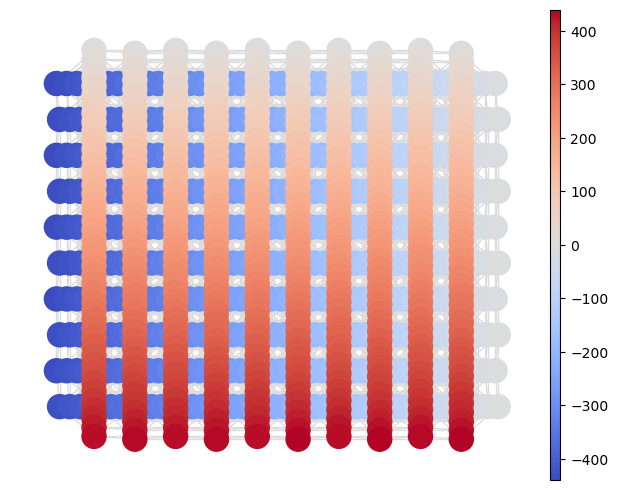

In [28]:
#visualize labelling
#label all the nodes in the graph as visible 1 or hidden 0 
n = G.number_of_nodes()
lin_biases = {i: (i-n/2) for i in range(n)}

dnx.draw_zephyr(G, linear_biases=lin_biases)

Number of nodes: 880
Number of visibles: 144
Number of hiddens: 736


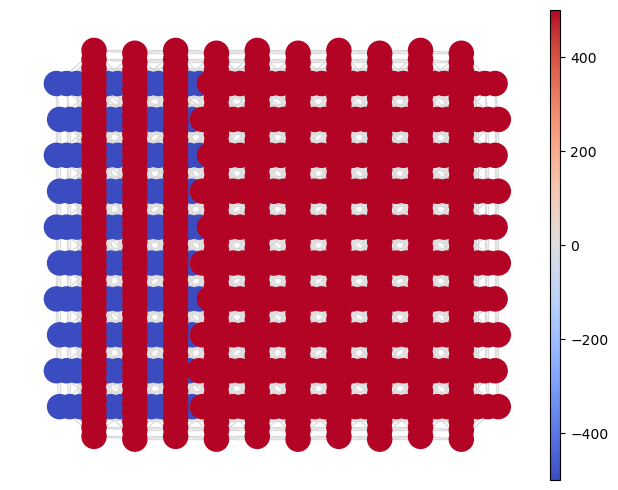

In [29]:
#label all the nodes in the graph as visible 1 or hidden 0 
n = G.number_of_nodes()
vh_nodearray = np.zeros(n, dtype=int) 


vh_nodearray[NUM_VISIBLE:] = 1  # second half as visible
node_labels = {i: 'visible' if i < NUM_VISIBLE else 'hidden' for i in range(n)}



NUM_HIDDEN = n-NUM_VISIBLE
print('Number of nodes:', n)
print('Number of visibles:', NUM_VISIBLE)
print('Number of hiddens:', NUM_HIDDEN)

draw_zephyr_hidden_visible(G, vh_nodearray)

# Remove nodes from G (may need to change how this is done)
#Note this is temporary to work around having too many nodes for this dataset

# Remove nodes from G if it has more visibles than our target
final_num_vis = NUM_VISIBLE   # <--  matches GRID_SHAPE automatically
vis_to_remove = NUM_VISIBLE- final_num_vis

if vis_to_remove > 0:
    # Remove nodes alternately from the start and end of the node list
    to_remove = []
    for i in range(vis_to_remove):
        if i % 2 == 0:
            to_remove.append(visible_nodes[i])
        else:
            to_remove.append(visible_nodes[-i])
    G.remove_nodes_from(to_remove)
    print(f"Removed {vis_to_remove} visible nodes to match target {final_num_vis}")


Updated number of visibles: 144
Updated number of hiddens: 656
Graph has 800 nodes and 7136 edges
V-V edges: 265, H-H edges: 4917, V-H edges: 1954


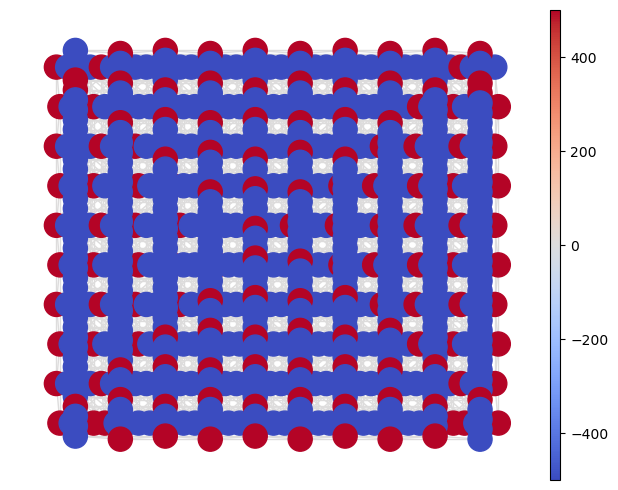

In [30]:
nodes_sorted = np.array(sorted(G.nodes()), dtype=int)

'''
Next is a very specific way of removing some nodes. 
Namely, these nodes (0 to 4K, n/2-4K to n/2+4K, and n-4K to n) 
are poorly connected (they are on the "edge" of the chip / graph)

'''
nodes_to_remove = np.array([], dtype = 'int')
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(0, 4*K)))
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(round(n/2)-4*K, round(n/2)+4*K)))
nodes_to_remove = np.concatenate((nodes_to_remove, np.arange(n-4*K, n)))

G.remove_nodes_from(nodes_to_remove)

# Relabel nodes to go from 0 to (new number of nodes - 1)
G = nx.convert_node_labels_to_integers(G, ordering='sorted')


visible_nodes_in_pixel_order = assign_visibles_by_grid(G, grid_shape=GRID_SHAPE, min_degree=3)  # min_degree optional
assert len(visible_nodes_in_pixel_order) == NUM_VISIBLE

# Relabel so visibles are 0..143 in pixel (row-major) order and then hiddens after that
G, mapping_old_to_new = relabel_visible_first(G, visible_nodes_in_pixel_order) # ewmoving this resulted in massive improvement in training

# Build vh_nodearray and node_labels consistent with your downstream code
n = G.number_of_nodes()
NUM_VISIBLE = GRID_SHAPE[0] * GRID_SHAPE[1]  # This should be 169 for 13x13
NUM_HIDDEN = n - NUM_VISIBLE
vh_nodearray = np.zeros(n, dtype=int)
vh_nodearray[:NUM_VISIBLE] = 1  # visibles are indices 0..143 now
node_labels = {i: 'visible' if i < NUM_VISIBLE else 'hidden' for i in range(n)}

# print stats
print('Updated number of visibles:', NUM_VISIBLE)
print('Updated number of hiddens:', NUM_HIDDEN)

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

draw_zephyr_hidden_visible(G, vh_nodearray)             # DWN’s Zephyr look

Graph has 800 nodes and 7136 edges
V-V edges: 265, H-H edges: 4917, V-H edges: 1954


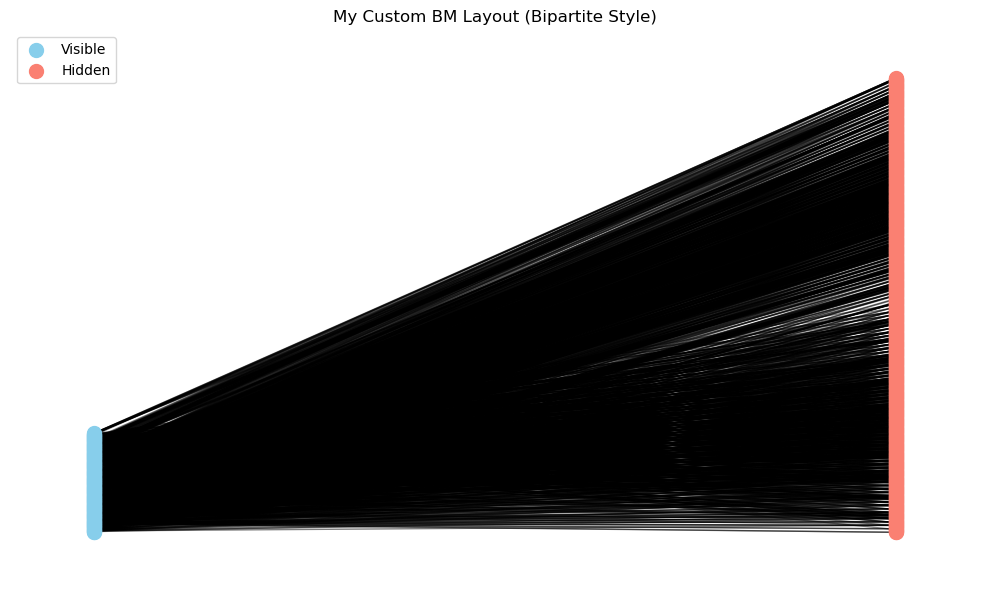

Building Boltzmann Machine from graph... 🏗️
Sanity check:
  dataset feature dim: 144
  model num_visible   : 144
  model num_hidden    : 656
  W_vh shape (should be V x H): (144, 656)
Starting PCD training on cpu for 50 epochs... 🏋️
Epoch 1/50 | Avg PCD Loss: -5.0451
Epoch 2/50 | Avg PCD Loss: -13.3259
Epoch 3/50 | Avg PCD Loss: -18.5964
Epoch 4/50 | Avg PCD Loss: -22.6782
Epoch 5/50 | Avg PCD Loss: -25.2788
Epoch 6/50 | Avg PCD Loss: -28.4383
Epoch 7/50 | Avg PCD Loss: -29.3383
Epoch 8/50 | Avg PCD Loss: -30.8717
Epoch 9/50 | Avg PCD Loss: -30.3974
Epoch 10/50 | Avg PCD Loss: -28.0185
Epoch 11/50 | Avg PCD Loss: -26.0858
Epoch 12/50 | Avg PCD Loss: -22.7729
Epoch 13/50 | Avg PCD Loss: -22.3897
Epoch 14/50 | Avg PCD Loss: -20.6035
Epoch 15/50 | Avg PCD Loss: -19.8778
Epoch 16/50 | Avg PCD Loss: -18.7756
Epoch 17/50 | Avg PCD Loss: -18.7648
Epoch 18/50 | Avg PCD Loss: -14.8470
Epoch 19/50 | Avg PCD Loss: -16.2956
Epoch 20/50 | Avg PCD Loss: -14.2845
Epoch 21/50 | Avg PCD Loss: -13.5827


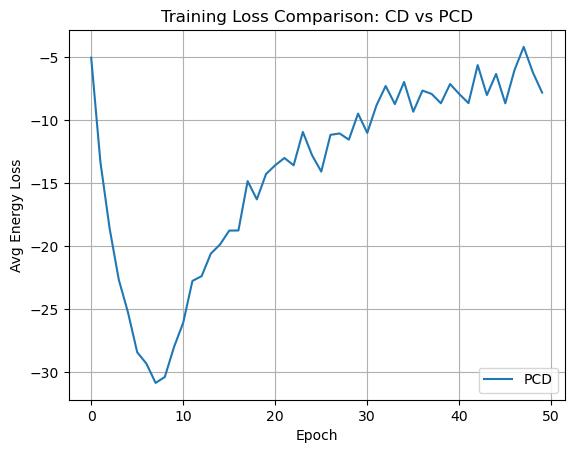

In [35]:
'''Hyperparameters here. 
num_gibbs_steps is an important addition, which determines 
how many gibbs steps are done for each sample in training
Increasing it increases training time linearly, unfortunately, 
and it is quite slow. '''
step_size = 0.0008# You can change this value for experiments 
l2_amount = 0.0001  # L2 regularization amount
num_epochs = 50
batch_size = 50  
num_gibbs_steps = 30
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)



# Print some graph statistics
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

visualize_bm_bipartite_layout(G, node_labels, title="My Custom BM Layout (Bipartite Style)")


# Use the factory function
# model_cd = graph_to_bm(G, node_labels)
model_pcd = graph_to_bm(G, node_labels)

print("Sanity check:")
print("  dataset feature dim:", X_data.shape[1])
print("  model num_visible   :", model_pcd.num_visible)
print("  model num_hidden    :", model_pcd.num_hidden)
# assert X_data.shape[1] == (model_pcd.num_visible, "Data V != Model V")

# optional: ensure W_vh orientation (V x H)
W_vv, W_hh, W_vh = model_pcd._get_masked_weights()
print("  W_vh shape (should be V x H):", tuple(W_vh.shape))
assert W_vh.shape == (model_pcd.num_visible, model_pcd.num_hidden)


# --- Training ---
optimizer_pcd = torch.optim.RMSprop(model_pcd.parameters(), lr=step_size, weight_decay=l2_amount)
pcd_losses = train_boltzmann_machine_pcd(model_pcd, data_loader, optimizer_pcd, num_epochs=num_epochs, k_steps=num_gibbs_steps, batch_size=batch_size, step_size=step_size)

# --- Plot training loss ---
plt.plot(pcd_losses, label='PCD')
plt.xlabel('Epoch')
plt.ylabel('Avg Energy Loss')
plt.title('Training Loss Comparison: CD vs PCD')
plt.legend()
plt.grid(True)
plt.show()


--- Generating samples using Gibbs Sampling ---
Running Gibbs sampler for 12 samples, 100 burn-in steps each... 🔥
  Gibbs sample 1/12
  Gibbs sample 2/12
  Gibbs sample 3/12
  Gibbs sample 4/12
  Gibbs sample 5/12
  Gibbs sample 6/12
  Gibbs sample 7/12
  Gibbs sample 8/12
  Gibbs sample 9/12
  Gibbs sample 10/12
  Gibbs sample 11/12
  Gibbs sample 12/12
Gibbs sampling complete.

Displaying generated images... 🖼️


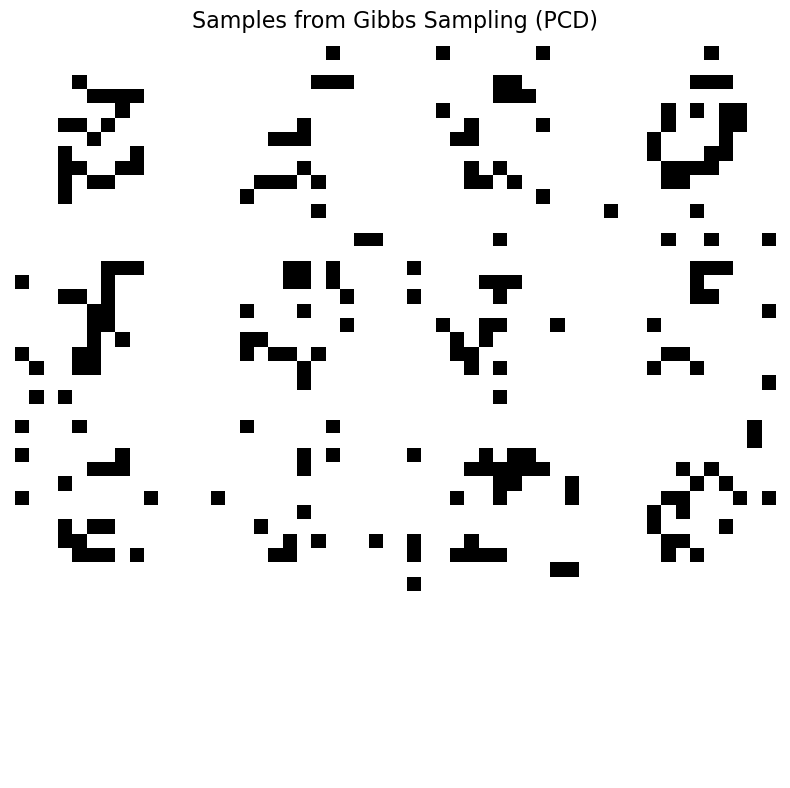

In [36]:
#--- Sampling & Visualization ---
num_gen_samples = 12
burn_in = 100


#need to find a way to speed up these sampling functions, so slow
print("\n--- Generating samples using Gibbs Sampling ---")
samples_pcd = sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs')


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples from Gibbs Sampling (PCD)")

In [ ]:
#--- Sampling & Visualization ---
num_gen_samples = 12
burn_in = 100


#need to find a way to speed up these sampling functions, so slow
print("\n--- Generating samples using Gibbs Sampling ---")
samples_pcd = sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs')


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples from Gibbs Sampling (PCD)")